In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import json

OUT_ROOT = Path(r"E:\jyp\ct_data_2d_preprocessed\Normal_LUNA16_training_ready_v1")
manifest_path = OUT_ROOT / "manifests" / "patient_manifest.csv"

manifest = pd.read_csv(manifest_path)

print("manifest rows:", len(manifest))
print(manifest[["patient_id", "safe_id", "patch_count", "ct_hu_npy"]].head())

# patch가 있는 환자 1명 선택
row = manifest[manifest["patch_count"] > 0].iloc[0]

ct_path = Path(row["ct_hu_npy"])
pure_path = Path(row["pure_lung_npy"])
organ_path = Path(row["organ_exclusion_npy"])
meta_path = Path(row["meta_json"])

ct = np.load(ct_path, mmap_mode="r")
pure = np.load(pure_path, mmap_mode="r")
organ = np.load(organ_path, mmap_mode="r")

print("\n========== NPY CHECK ==========")
print("patient_id:", row["patient_id"])
print("ct shape:", ct.shape, "dtype:", ct.dtype, "min/max:", ct.min(), ct.max())
print("pure shape:", pure.shape, "dtype:", pure.dtype, "unique:", np.unique(pure))
print("organ shape:", organ.shape, "dtype:", organ.dtype, "unique:", np.unique(organ))

with open(meta_path, "r", encoding="utf-8") as f:
    meta = json.load(f)

print("\n========== META CHECK ==========")
print("shape_zyx:", meta["shape_zyx"])
print("spacing_xyz:", meta["spacing_xyz"])
print("ct_dtype:", meta["ct_dtype"])
print("mask_dtype:", meta["mask_dtype"])

manifest rows: 362
  patient_id                safe_id  patch_count  \
0  normal001  normal001__104e7cb873        20993   
1  normal002  normal002__d886c791fa        22598   
2  normal003  normal003__a8549e0718        31194   
3  normal004  normal004__9190565aec        27154   
4  normal005  normal005__41ac5e1f40        32848   

                                           ct_hu_npy  
0  E:\jyp\ct_data_2d_preprocessed\Normal_LUNA16_t...  
1  E:\jyp\ct_data_2d_preprocessed\Normal_LUNA16_t...  
2  E:\jyp\ct_data_2d_preprocessed\Normal_LUNA16_t...  
3  E:\jyp\ct_data_2d_preprocessed\Normal_LUNA16_t...  
4  E:\jyp\ct_data_2d_preprocessed\Normal_LUNA16_t...  

========== NPY CHECK ==========
patient_id: normal001
ct shape: (251, 512, 512) dtype: int16 min/max: -1024 1667
pure shape: (251, 512, 512) dtype: uint8 unique: [0 1]
organ shape: (251, 512, 512) dtype: uint8 unique: [0 1]

========== META CHECK ==========
shape_zyx: [251, 512, 512]
spacing_xyz: [0.71875, 0.71875, 1.0]
ct_dtype: int16

In [7]:
import pandas as pd
import numpy as np
from pathlib import Path

# 위에서 고른 환자 row 사용
patch_csv = Path(row["patch_csv"])
patch_df = pd.read_csv(patch_csv)

print("patch rows:", len(patch_df))
print(patch_df[["local_z", "y0", "x0", "y1", "x1", "position_bin"]].head())

# patch 하나 선택
p = patch_df.iloc[0]

z = int(p["local_z"])
y0 = int(p["y0"])
x0 = int(p["x0"])
y1 = int(p["y1"])
x1 = int(p["x1"])

ct_patch = ct[z, y0:y1, x0:x1]
pure_patch = pure[z, y0:y1, x0:x1]
organ_patch = organ[z, y0:y1, x0:x1]

print("\n========== PATCH CHECK ==========")
print("ct_patch shape:", ct_patch.shape, "dtype:", ct_patch.dtype)
print("pure_patch shape:", pure_patch.shape, "unique:", np.unique(pure_patch))
print("organ_patch shape:", organ_patch.shape, "unique:", np.unique(organ_patch))
print("position_bin:", p["position_bin"])
print("pure_lung_patch_ratio:", p["pure_lung_patch_ratio"])
print("organ_patch_ratio:", p["organ_patch_ratio"])

patch rows: 20993
   local_z   y0   x0   y1   x1   position_bin
0       11  336  144  368  176  lower_central
1       12  336  144  368  176  lower_central
2       13  320  176  352  208  lower_central
3       13  336  128  368  160  lower_central
4       13  336  144  368  176  lower_central

========== PATCH CHECK ==========
ct_patch shape: (32, 32) dtype: int16
pure_patch shape: (32, 32) unique: [0 1]
organ_patch shape: (32, 32) unique: [0 1]
position_bin: lower_central
pure_lung_patch_ratio: 0.7685546875
organ_patch_ratio: 0.0078125


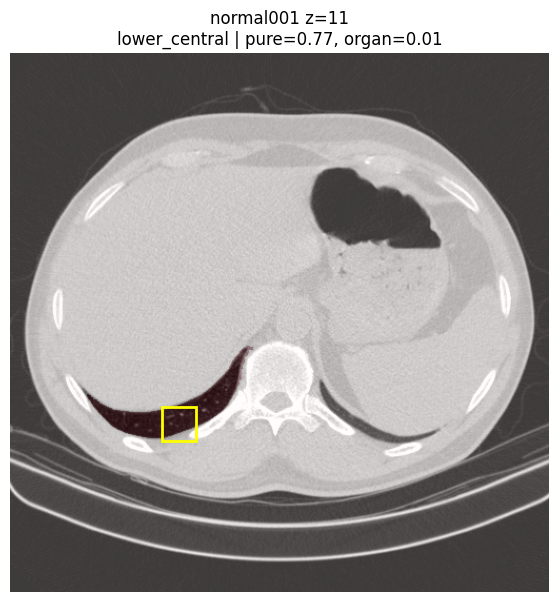

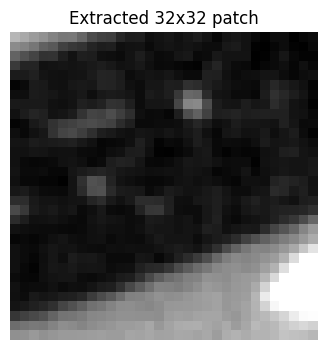

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def hu_to_uint8(arr, hu_min=-1000, hu_max=400):
    arr = np.clip(arr.astype(np.float32), hu_min, hu_max)
    arr = (arr - hu_min) / (hu_max - hu_min + 1e-8)
    return (arr * 255).astype(np.uint8)

slice_img = hu_to_uint8(ct[z])
slice_pure = pure[z] > 0

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(slice_img, cmap="gray")
ax.imshow(slice_pure, cmap="Reds", alpha=0.25)

rect = patches.Rectangle(
    (x0, y0),
    x1 - x0,
    y1 - y0,
    linewidth=2,
    edgecolor="yellow",
    facecolor="none",
)
ax.add_patch(rect)

ax.set_title(
    f"{row['patient_id']} z={z}\n"
    f"{p['position_bin']} | pure={p['pure_lung_patch_ratio']:.2f}, organ={p['organ_patch_ratio']:.2f}"
)
ax.axis("off")
plt.show()

plt.figure(figsize=(4, 4))
plt.imshow(hu_to_uint8(ct_patch), cmap="gray")
plt.title("Extracted 32x32 patch")
plt.axis("off")
plt.show()

In [9]:
from pathlib import Path

ROOT = Path(r"E:\jyp\ct_data_2d_preprocessed\Normal_LUNA16_training_ready_v1")

def folder_size_gb(path):
    total = 0
    for p in Path(path).rglob("*"):
        if p.is_file():
            total += p.stat().st_size
    return total / (1024 ** 3)

for name in ["volumes_npy", "patch_index_by_patient", "manifests", "configs", "logs"]:
    p = ROOT / name
    if p.exists():
        print(name, f"{folder_size_gb(p):.2f} GB")

print("TOTAL", f"{folder_size_gb(ROOT):.2f} GB")

volumes_npy 95.28 GB
patch_index_by_patient 27.08 GB
manifests 0.00 GB
configs 0.00 GB
logs 0.00 GB
TOTAL 122.36 GB
